# 0. Title: Hotel Booking Cancellation Analysis

In [1]:
library(tidyverse)
library(rsample)
library(glmnet)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loaded glmnet 4.1-8



# Assignment #1

## I. Data description

### Read the data

In [2]:
hotel_bookings <- read_csv("https://vincentarelbundock.github.io/Rdatasets/csv/bayesrules/hotel_bookings.csv")
head(hotel_bookings)

Rows: 1000 Columns: 33
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (13): hotel, arrival_date_month, meal, country, market_segment, distrib...
dbl  (19): rownames, is_canceled, lead_time, arrival_date_year, arrival_date...
date  (1): reservation_status_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


rownames,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,⋯,deposit_type,agent,company,days_in_waiting_list,customer_type,average_daily_rate,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<date>
1,City Hotel,1,1,2015,September,40,30,0,2,⋯,Non Refund,50,NULL,0,Transient,98.10,0,0,Canceled,2015-09-29
2,Resort Hotel,1,19,2016,March,12,19,2,4,⋯,No Deposit,240,NULL,0,Transient,70.17,0,1,Canceled,2016-03-02
3,Resort Hotel,0,9,2017,August,31,1,0,4,⋯,No Deposit,241,NULL,0,Transient,193.40,0,1,Check-Out,2017-08-05
4,Resort Hotel,0,110,2016,November,46,11,0,1,⋯,No Deposit,314,NULL,0,Transient,36.24,1,0,Check-Out,2016-11-12
5,City Hotel,0,329,2017,July,30,27,0,2,⋯,No Deposit,9,NULL,0,Transient,89.10,0,1,Check-Out,2017-07-29
6,Resort Hotel,0,212,2017,August,35,31,2,8,⋯,No Deposit,143,NULL,0,Transient,89.75,0,0,Check-Out,2017-09-10


### More information about the dataset
This data includes the hotel booking information of two different types located in Portugal, with one being in resort region and the other in city area of Lisbon. It includes both effective and cancelled bookings of the arrival dates between the 1st of July of 2015 and the 31st of August 2017. To ensure the privacy of the customers, traceable hotel and customer identification was omitted.

#### Number of observations and variables
This data consists of 1000 rows of observation with 33 columns (a subset of the data from the original source cited at the bottom). 

#### A table with names and types of variables
Below is the list of names and descriptions for the 32 variables in the dataset:
- `hotel`: "Resort Hotel" or "City Hotel"

- `is_canceled`: whether the booking was cancelled (0 = not canceled; 1 = canceled)

- `lead_time`: number of days between booking and arrival

- `arrival_date_year`: year of scheduled arrival

- `arrival_date_month`: month of scheduled arrival

- `arrival_date_week_number`: week of scheduled arrival

- `arrival_date_day_of_month`: day of month of scheduled arrival

- `stays_in_weekend_nights`: number of reserved weekend nights

- `stays_in_week_nights`: number of reserved week nights

- `adults`: number of adults in booking

- `children`: number of children

- `babies`: number of babies

- `meal`: whether the booking includes breakfast (BB = bed & breakfast), breakfast and dinner (HB = half board), or breakfast, lunch, and dinner (FB = full board)

- `country`: guest's country of origin

- `market_segment`: market segment designation (eg: TA = travel agent, TO = tour operator)

- `distribution_channel`: booking distribution channel (eg: TA = travel agent, TO = tour operator)

- `is_repeated_guest`: whether or not booking was made by a repeated guest (0 = first-time visitors; 1 = repeat customers)

- `previous_cancellations`: guest's number of previous booking cancellations

- `previous_bookings_not_canceled`: guest's number of previous bookings that weren't cancelled

- `reserved_room_type`: code for type of room reserved by guest (code is presented instead of designation for anonymity reasons)

- `assigned_room_type`: code for type of room assigned by hotel (code is presented instead of designation for anonymity reasons)

- `booking_changes`: number of changes made to the booking

- `deposit_type`: No Deposit, Non Refund, Refundable

- `agent`: booking travel agency

- `company`: booking company

- `days_in_waiting_list`: number of days the guest waited for booking confirmation

- `customer_type`: Contract, Group, Transient, Transient-party (a transient booking tied to another transient booking)

- `average_daily_rate`: average hotel cost per day

- `required_car_parking_spaces`: number of parking spaces the guest needed

- `total_of_special_requests`: number of guest special requests

- `reservation_status`: Canceled, Check-Out, No-Show

- `reservation_status_date`: when the guest cancelled or checked out\.

(see below code for more information on the types of each )

#### Data collection process
Data was extracted from the hotels "Property Management System (PMS)" SQL databases.

#### Data source and citation
Nuno Antonio, Ana de Almeida, and Luis Nunes (2019). "Hotel booking demand datasets." Data in Brief (22): 41-49. https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/hotels.csv/.

In [3]:
####### Overview of hotel_bookings ######
# number of rows & columns
dim(hotel_bookings)

# a table with names & types of variables
glimpse(hotel_bookings) 

[1] 1000   33

Rows: 1,000
Columns: 33
$ rownames                       <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, …
$ hotel                          <chr> "City Hotel", "Resort Hotel", "Resort H…
$ is_canceled                    <dbl> 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, …
$ lead_time                      <dbl> 1, 19, 9, 110, 329, 212, 14, 58, 88, 37…
$ arrival_date_year              <dbl> 2015, 2016, 2017, 2016, 2017, 2017, 201…
$ arrival_date_month             <chr> "September", "March", "August", "Novemb…
$ arrival_date_week_number       <dbl> 40, 12, 31, 46, 30, 35, 5, 41, 20, 14, …
$ arrival_date_day_of_month      <dbl> 30, 19, 1, 11, 27, 31, 29, 3, 17, 5, 22…
$ stays_in_weekend_nights        <dbl> 0, 2, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 1, …
$ stays_in_week_nights           <dbl> 2, 4, 4, 1, 2, 8, 0, 5, 3, 3, 1, 1, 1, …
$ adults                         <dbl> 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, …
$ children                       <dbl> 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, …
$ babies        

## II. Question
In this project, I'm interested in examining the factors that influence customer's likeliness to rebook with same hotel to suggest improvements for hotels to increase their customer stickiness. What booking and guest characteristics are associated with a customer's likelihood of returning to the same hotel, or vice versa? Using `is_repeated_guest` as the binary response variable, this study focuses on **inference**: estimating the direction and magnitude of effects from covariates including `average_daily_rate`, `total_of_special_requests`, `days_in_waiting_list`, `customer_type`, `adults`, `children`, `babies`, and `lead_time`. Variables such as `hotel`, `market_segment`, and `deposit_type` can serve as controls to account for structural differences across booking contexts. 

## III. Exploratory data analysis & visualization

### Exploratory data analysis

#### Clean and wrangle
In this section, I omitted `rownames` as it does not provide any information about the booking, and turned any categorical variables into factors. The result is shown in the table below.

In [4]:
hotel_clean <- hotel_bookings |>
  select(-rownames) |>
  mutate(
    is_repeated_guest = factor(is_repeated_guest),
    hotel             = factor(hotel),
    customer_type     = factor(customer_type),
    meal              = factor(meal),
    deposit_type      = factor(deposit_type),
    market_segment    = factor(market_segment),
    distribution_channel = factor(distribution_channel),
    reservation_status   = factor(reservation_status),
    is_canceled          = factor(is_canceled),
    arrival_date_month   = factor(arrival_date_month, levels = month.name)
  )

glimpse(hotel_clean)

Rows: 1,000
Columns: 32
$ hotel                          <fct> City Hotel, Resort Hotel, Resort Hotel,…
$ is_canceled                    <fct> 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, …
$ lead_time                      <dbl> 1, 19, 9, 110, 329, 212, 14, 58, 88, 37…
$ arrival_date_year              <dbl> 2015, 2016, 2017, 2016, 2017, 2017, 201…
$ arrival_date_month             <fct> September, March, August, November, Jul…
$ arrival_date_week_number       <dbl> 40, 12, 31, 46, 30, 35, 5, 41, 20, 14, …
$ arrival_date_day_of_month      <dbl> 30, 19, 1, 11, 27, 31, 29, 3, 17, 5, 22…
$ stays_in_weekend_nights        <dbl> 0, 2, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 1, …
$ stays_in_week_nights           <dbl> 2, 4, 4, 1, 2, 8, 0, 5, 3, 3, 1, 1, 1, …
$ adults                         <dbl> 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, …
$ children                       <dbl> 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, …
$ babies                         <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ meal          

#### Missing values
I located all missing values from each column. In variables `agent` and `company`, `NA` values were presented as strings "NULL". I transformed them into `NA` values before counting the total missing values. We can see that `agent` and `company` have the most missing values out of all variables, and that the variable **`company` has missing values of 95.1% (over 20%)**.

In [5]:
hotel_clean <- hotel_clean |>
  mutate(
    agent   = na_if(agent, "NULL"),
    company = na_if(company, "NULL")
  )

missing_summary <- hotel_clean |>
  summarise(across(everything(), ~ sum(is.na(.)))) |>
  pivot_longer(everything(), names_to = "Variable", values_to = "Missing") |>
  mutate(
    Total      = nrow(hotel_clean),
    Proportion = round(Missing / Total * 100, 2)
  ) |>
  arrange(desc(Missing))

missing_summary

Variable,Missing,Total,Proportion
<chr>,<int>,<int>,<dbl>
company,951,1000,95.1
agent,128,1000,12.8
hotel,0,1000,0.0
is_canceled,0,1000,0.0
lead_time,0,1000,0.0
arrival_date_year,0,1000,0.0
arrival_date_month,0,1000,0.0
arrival_date_week_number,0,1000,0.0
arrival_date_day_of_month,0,1000,0.0


#### Class imbalance in different variables

- `is_repeated_guest`

In [6]:
hotel_clean |>
  count(is_repeated_guest) |>
  mutate(proportion = round(n / sum(n) * 100, 2))

is_repeated_guest,n,proportion
<fct>,<int>,<dbl>
0,968,96.8
1,32,3.2


- `customer_type`

In [7]:
hotel_clean |>
  count(customer_type) |>
  mutate(proportion = round(n / sum(n) * 100, 2))

customer_type,n,proportion
<fct>,<int>,<dbl>
Contract,28,2.8
Group,4,0.4
Transient,742,74.2
Transient-Party,226,22.6


- `hotel`

In [8]:
hotel_clean |>
  count(hotel) |>
  mutate(proportion = round(n / sum(n) * 100, 2))

hotel,n,proportion
<fct>,<int>,<dbl>
City Hotel,642,64.2
Resort Hotel,358,35.8


- `deposit_type`

In [9]:
hotel_clean |>
  count(deposit_type) |>
  mutate(proportion = round(n / sum(n) * 100, 2))

deposit_type,n,proportion
<fct>,<int>,<dbl>
No Deposit,881,88.1
Non Refund,116,11.6
Refundable,3,0.3


- `is_canceled`

In [10]:
hotel_clean |>
  count(is_canceled) |>
  mutate(proportion = round(n / sum(n) * 100, 2))

is_canceled,n,proportion
<fct>,<int>,<dbl>
0,634,63.4
1,366,36.6


### Visualization
#### What the plot shows
The plot displays the distribution of the average daily rate (in euros) across customer types, comparing first-time and returning guests coloured in blue and orange, repectively, in the boxplots faceted by hotel type. Three variables, `average_daily_rate`, `customer_type`, and `is_repeated_guest` are examined while being separated using `hotel` variable. In addition, I filtered out some high-rate outliers (> €500) in `average_daily_rate`, which are mainly in City Hotel, to keep the plot readable.
#### Pattern in the plot
Across both hotel types, returning guests tend to show a narrower and slightly lower distribution of average daily rates compared to new guests within the same customer type, suggesting that repeat visitors may be more price-sensitive or tend to book during lower-demand periods. This pattern is most visible among Transient customers, who make up the majority of bookings, where the interquartile range for returning guests is compressed toward the lower end of the rate spectrum. In Resort Hotels, the difference between first-time and returning guests in the Transient category is more pronounced than in City Hotels, where rates are more tightly clustered across both guest types. However, it is worth mentioning that **Transient** customers made up most of `customer_type` by 74.2%, and that most customers in the dataset are **new** customers. We need to be extra cautious if we want to make interpretations about the other groups that may not have a sufficient number of observations, for instance Contract customers or Group customers.
#### What the plot suggests for my question
These observations suggest that **`average_daily_rate`** carries meaningful signal for distinguishing returning from first-time guests, supporting its inclusion as a **key covariate in the inference model**. The interaction between hotel type and the rate distribution further reinforces **treating hotel as a control variable**, as the relationship between pricing and repeat visits does not behave uniformly across hotel contexts.

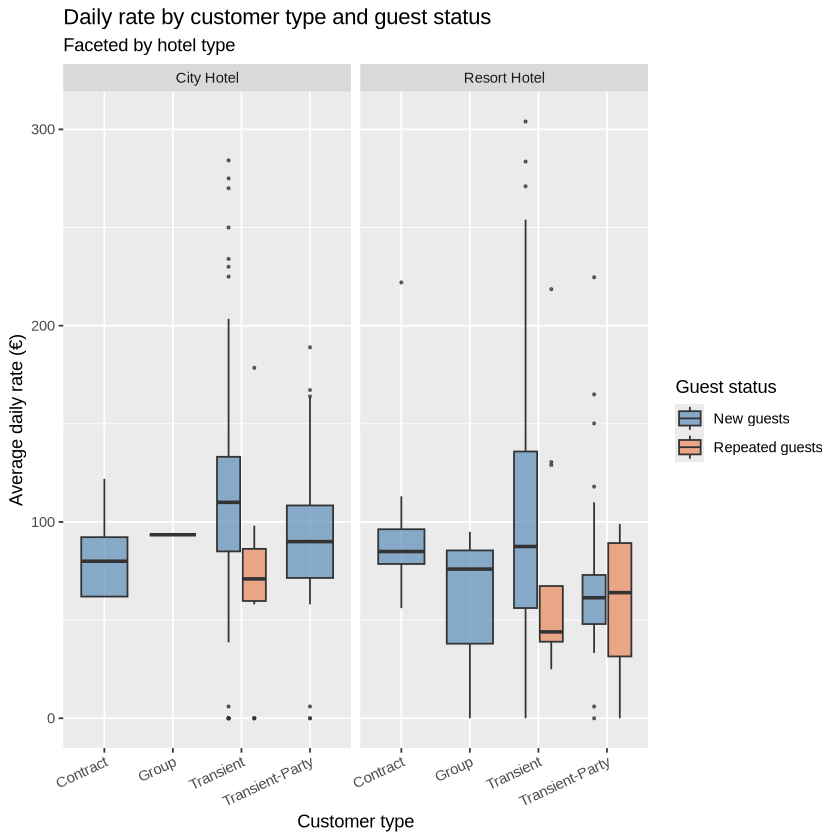

In [11]:
hotel_clean |>
  filter(average_daily_rate < 500) |> 
  ggplot(aes(x = customer_type,
             y = average_daily_rate,
             fill = is_repeated_guest)) +
  geom_boxplot(alpha = 0.7, outlier.size = 0.5) +
  facet_wrap(~ hotel) +
  scale_fill_manual(values = c("0" = "#5B8DB8", "1" = "#E8885A"),
                    labels = c("0" = "New guests", 
                               "1" = "Repeated guests")) +
  labs(
    title = "Daily rate by customer type and guest status",
    subtitle = "Faceted by hotel type",
    x = "Customer type",
    y = "Average daily rate (€)",
    fill = "Guest status"
  ) +
  theme(axis.text.x = element_text(angle = 25, hjust = 1))

# Reviewed question
_What variables are most associated with the likelihood of customers cancelling hotel bookings?_ Using `is_canceled` as the binary response variable, this study focuses on **inference**: identifying which covariates have a statistically meaningful association with cancellation after variable selection. This question is observational, so no causal 
claims will be made.

In Assignment 1, I proposed a question to examine what characteristics are related to customers' repeated visits to a hotel using `is_repeated` as the response variable. However, after discussing with my group mates during Monday's lecture, we decided to do an inference problem on the variable `is_canceled` as two of the group members have already done this for their first assignment. That said, I revised the question to examining the characteristics strongly associated with customers cancelling hotel bookings to better align with our final project.

# Assignment #2

# 1. Methods & Plan
## 1a. Rethinking the question & choosing a method
Karen, who also selected a different question in the first assignment, and I decided to each pick a method between Stepwise selection and LASSO to train our models and make inference about our data.  
To be grounded in the response variable `is_canceled` and justify why __post-LASSO__ would be a great methodological choice, here are three reasons that showcase the validity of the method:  
  
1. `is_canceled` is binary, so we use logistic regression as the model.  
2. There are many covariates in the data, including variables with multiple classes which each creates a new covariate. By using LASSO, we benefit from its automatic variable selection process.  
3. After implementing LASSO, we have to use post-LASSO to acquire the unbiased coefficients in order to make the correct inference.

## 1b. Proposed method
I will use post-LASSO logistic regression to address the question in this assignment. Since the dataset contains a large number of covariates, it is reasonable to use LASSO as it penalizes irrelevant predictors to as less as zero and conduct an automatic variable selection process. In the post-LASSO step, we fit the data using Least Square with the variables selected in LASSO to retrieve the unbiased coefficient, so that we can make a better and correct inference.  

## 1c. Assumptions & limitations
__Assumptions:__  
1. __Binary response:__ The Logistic regression model we use assumes a binary response, which `is_canceled` satisfied the assumption.
2. __Independence of the observation:__ Logistic regression assumes independence among observations. We have to be cautious about the observational data as some observations might be correlated.
3. __Multicollinearity:__ Even though LASSO tolerates multicollinearity better than Stepwise, severe multicollinearity (e.g. `reservation_status`) can still distort variable selection. It's better that we keep an eye out for this issue. To solve this issue in this assignment, I will exclude the variables like `reservation_status` & `reservation_status_date` that directly carries out our response variable.

__Limitations:__  
1. __Inference after selection:__ we will encounter post inference problem if we conduct variable selection and inference on the same dataset. To solve this limitation, we have to __split the data into training and testing sets__.
2. __Class imbalance:__ `is_canceled` has a slight class imbalance as explored in Assignment #1. However, some varaibles in the dataset have severe class imbalance, with some of them only containing one data point in a single class. We have to pay attention to it in our project. To minimize the effect of imbalanced response variable, I will use __`type.measure = "auc"`__ in `cv.glmnet()`.
3. __Variables with too many classes:__ In the dataset, variables such as `agent`, `company`, and `country` include too many classes with limited data points in each class, which results in too much noises in the dummy variables created in LASSO. These variables will also be omitted to solve this problem.
4. __No causal relationship can be claimed:__ Since the project is based on observational data, it limits the possibility of claiming any causality.

# Computational Code & Output

## 2a. Computational code & method implementation

In [12]:
# --- Data preparation ---

# Remove outcome-leaking and non-informative variables
hotel_model <- hotel_bookings |>
  select(-rownames,                  # not used in analysis
         -reservation_status,        # directly encodes cancellation
         -reservation_status_date,   # same issue
         -arrival_date_week_number,  # redundant with month
         -arrival_date_day_of_month, 
         -agent,                     # contains too much classes, which  #
         -company,                   # leads to tons of dummy variables  #
         -country) |>                # that generate noises              #
  mutate(is_canceled = as.numeric(as.character(is_canceled))) |>
  drop_na()   # LASSO requires complete cases

# Set seed for reproducibility
set.seed(42)

# Stratified split — 80% train, 20% test
# strata ensures is_canceled proportion is preserved in both sets
split <- initial_split(hotel_model, prop = 0.8, strata = is_canceled)
hotel_train <- training(split)
hotel_test <- testing(split)

# Build model matrix (converts factors to dummies automatically)
model_X_train <- model.matrix(is_canceled ~ . - 1, data = hotel_train)
model_Y_train <- hotel_train$is_canceled


In [13]:
# Step 1: LASSO on training set only
set.seed(52)
lasso_fit <- cv.glmnet(model_X_train, 
                         model_Y_train, 
                         family = "binomial", 
                         type.measure = "auc", # auc is used because there is a class imbalance in is_canceled
                         alpha = 1,
                         nfolds = 3)

best_lambda <- lasso_fit$lambda.1se  # used 1se instead of lambda.min for better interpretability

# Step 2: Extract selected variables from training LASSO
lasso_coefs   <- coef(lasso_fit, s = best_lambda)
selected_vars <- rownames(lasso_coefs)[which(lasso_coefs[, 1] != 0)]
selected_vars <- selected_vars[selected_vars != "(Intercept)"]

cat("Variables selected by LASSO:", length(selected_vars), "\n")  # shows the number of variables that are selected using LASSO
lasso_coefs  # shows the variables that are selected using LASSO

Variables selected by LASSO: 10 


62 x 1 sparse Matrix of class "dgCMatrix"
                                          s1
(Intercept)                    -1.2005842251
hotelCity Hotel                 .           
hotelResort Hotel               .           
lead_time                       0.0009827224
arrival_date_year               .           
arrival_date_monthAugust        .           
arrival_date_monthDecember      .           
arrival_date_monthFebruary      .           
arrival_date_monthJanuary       .           
arrival_date_monthJuly          .           
arrival_date_monthJune          .           
arrival_date_monthMarch         .           
arrival_date_monthMay           .           
arrival_date_monthNovember      .           
arrival_date_monthOctober       .           
arrival_date_monthSeptember     .           
stays_in_weekend_nights         .           
stays_in_week_nights            .           
adults                          0.0374522998
children                        .           
babies       

In [14]:
# Step 3: Post-LASSO logistic regression on training set
hotel_train_postlasso             <- as.data.frame(model_X_train[, selected_vars])
hotel_train_postlasso$is_canceled <- as.numeric(model_Y_train)

postlasso_fit <- glm(is_canceled ~ .,
                     data   = hotel_train_postlasso,
                     family = "binomial")

summary(postlasso_fit)

# Step 4: Evaluate on test set
model_X_test <- model.matrix(is_canceled ~ . - 1, data = hotel_test)

# Add any columns present in training but missing in test as zeros (to fix warning message)
missing_cols <- setdiff(selected_vars, colnames(model_X_test))
if (length(missing_cols) > 0) {
  empty_cols   <- matrix(0,
                         nrow     = nrow(model_X_test),
                         ncol     = length(missing_cols),
                         dimnames = list(NULL, missing_cols))
  model_X_test <- cbind(model_X_test, empty_cols)
}

hotel_test_selected <- model_X_test[, selected_vars, drop = FALSE]

predicted_probs  <- predict(postlasso_fit,
                            newdata = as.data.frame(hotel_test_selected), 
                            type = "response")

predicted_labels <- ifelse(predicted_probs > 0.5, 1, 0)

# Step 5: Confusion matrix on test set
conf_matrix <- table(Predicted = predicted_labels, Actual = hotel_test$is_canceled)
conf_matrix


Call:
glm(formula = is_canceled ~ ., family = "binomial", data = hotel_train_postlasso)

Coefficients:
                                Estimate Std. Error z value Pr(>|z|)    
(Intercept)                    -2.806206   0.485497  -5.780 7.47e-09 ***
lead_time                       0.004156   0.001107   3.754 0.000174 ***
adults                          0.429811   0.208280   2.064 0.039054 *  
`market_segmentOffline TA/TO`  -1.076021   0.398594  -2.700 0.006944 ** 
`market_segmentOnline TA`       0.694801   0.361642   1.921 0.054701 .  
`distribution_channelTA/TO`     0.717452   0.428250   1.675 0.093873 .  
booking_changes                -0.973853   0.271874  -3.582 0.000341 ***
`deposit_typeNon Refund`       19.099662 633.909337   0.030 0.975963    
average_daily_rate              0.006809   0.002320   2.935 0.003332 ** 
required_car_parking_spaces   -17.518297 851.386226  -0.021 0.983584    
total_of_special_requests      -1.176761   0.162254  -7.253 4.09e-13 ***
---
Signif. codes:  

         Actual
Predicted   0   1
        0 119  30
        1   8  44

## 2b. Visualization

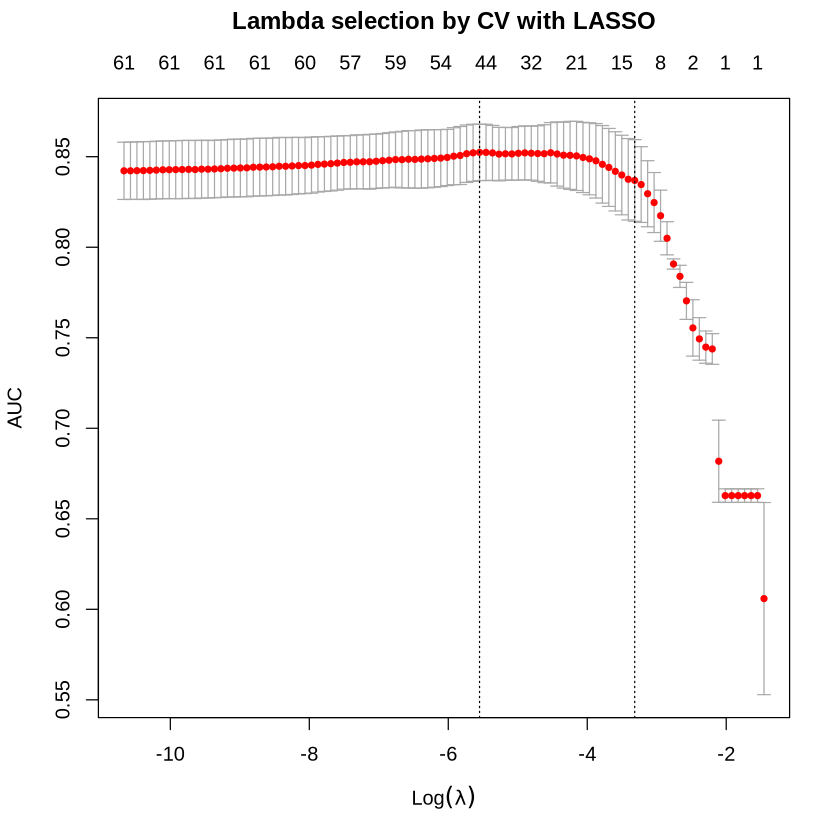

In [15]:
plot(lasso_fit, main = "Lambda selection by CV with LASSO\n\n")

## 2c. Interpretation
1. After using LASSO with `type.measure = "auc"` and `nfolds = 3`, it selects 10 variables from the model, namely `lead_time`, `adults`, `market_segmentOffline`, `market_segmentOnline TA`, `distribution_channelTA/TO`, `booking_changes`, `deposit_typeNon Refund`, `average_daily_rate`, `required_car_parking_spaces`, and `total_of_special_requests`.
2. By looking at the generated confusion matrix, we can conclude that the sensitivity is 119 / (119 + 8), which is around 0.9370, and that specificity is 44 / (30 + 44), which is around 0.5946. This model is better at predicting `is_canceled = 1`.

## Declaration of Ethical AI Use
I used Claude to help with code debugging.